# Portfolio Snapshots — 权重变化可视化

本教程展示如何利用 `RunResult.snapshots` 记录回测过程中每一个 bar 的组合优化结果和持仓状态。

**策略设定：**
- **标的池**：沪深300ETF (510300.SS)、黄金ETF (518880.SS)、纳指100ETF (513100.SS)
- **信号**：SimpleMomentum(20) > 0（动量为正则入选）
- **组合优化器对比**：EqualWeightOptimizer（等权） vs TopNRankingOptimizer（按动量排名加权）
- **调仓频率**：每 10 个交易日

通过 `result.weights_df()` 和 `result.adj_weights_df()` 可以直接获取权重时序 DataFrame，用于绘制权重变化曲线。

## 1. 下载数据

In [1]:
from oxq.data import LocalMarketDataProvider, YFinanceDownloader

SYMBOLS = ("510300.SS", "518880.SS", "513100.SS")
SYMBOL_NAMES = {
    "510300.SS": "沪深300ETF",
    "518880.SS": "黄金ETF",
    "513100.SS": "纳指100ETF",
}

DATA_START = "2024-12-01"  # warmup for indicators
START = "2025-01-01"
END = "2026-03-17"

# Download if not cached locally
provider = LocalMarketDataProvider()
dl = YFinanceDownloader()
for symbol in SYMBOLS:
    try:
        bars = provider.get_bars(symbol, DATA_START, END)
        if len(bars) > 0:
            print(f"  {symbol} ({SYMBOL_NAMES[symbol]}) — cached, {len(bars)} bars")
            continue
    except Exception:
        pass
    dl.download(symbol, DATA_START, END)
    print(f"  {symbol} ({SYMBOL_NAMES[symbol]}) — downloaded")

  510300.SS (沪深300ETF) — cached, 310 bars
  518880.SS (黄金ETF) — cached, 310 bars
  513100.SS (纳指100ETF) — cached, 311 bars


## 2. 构建策略

使用 `Threshold` 信号配合 `SimpleMomentum` 指标：当 20 日动量 > 0 时发出买入信号。

构建两个策略进行对比：
- **EqualWeightOptimizer**：入选标的等权分配
- **TopNRankingOptimizer**：按动量分数（mom20）归一化加权，动量越强权重越高

In [2]:
from oxq.core import Engine, Strategy
from oxq.indicators import SimpleMomentum
from oxq.portfolio.optimizers import EqualWeightOptimizer, TopNRankingOptimizer
from oxq.rules.constraint import RebalanceFrequencyRule
from oxq.signals import Threshold
from oxq.trade import SimBroker
from oxq.universe import StaticUniverse


def make_signal():
    """Create a fresh Threshold signal with SimpleMomentum(20) indicator."""
    sig = Threshold()
    sig.required_indicators = {
        "mom20": (SimpleMomentum(), {"column": "close", "period": 20}),
    }
    return sig


# --- 策略 A: EqualWeight ---
strategy_ew = Strategy(
    name="momentum_equal_weight",
    hypothesis="动量为正的资产等权配置，每10日调仓",
    universe=StaticUniverse(SYMBOLS),
    signals={"mom_positive": (make_signal(), {"column": "mom20", "threshold": 0, "relationship": "gt"})},
    portfolio=EqualWeightOptimizer(),
)

# --- 策略 B: TopNRanking ---
strategy_topn = Strategy(
    name="momentum_topn_ranking",
    hypothesis="按动量分数归一化加权，动量越强权重越高",
    universe=StaticUniverse(SYMBOLS),
    signals={"mom_positive": (make_signal(), {"column": "mom20", "threshold": 0, "relationship": "gt"})},
    portfolio=TopNRankingOptimizer(score_col="mom20", n=3, max_weight=0.9),
)

print("策略 A: EqualWeightOptimizer — 入选标的等权")
print("策略 B: TopNRankingOptimizer — 按 mom20 分数归一化加权")
print(f"标的: {', '.join(SYMBOL_NAMES[s] for s in SYMBOLS)}")

策略 A: EqualWeightOptimizer — 入选标的等权
策略 B: TopNRankingOptimizer — 按 mom20 分数归一化加权
标的: 沪深300ETF, 黄金ETF, 纳指100ETF


## 3. 运行回测

In [3]:
run_kwargs = dict(
    market=LocalMarketDataProvider(),
    broker=SimBroker(),
    start=START,
    end=END,
    initial_cash=1_000_000.0,
    lot_size=100,
    data_start=DATA_START,
    rules=[RebalanceFrequencyRule(interval_days=10)],
)

result_ew = Engine().run(strategy_ew, **run_kwargs)

# TopNRanking needs a fresh broker
run_kwargs["broker"] = SimBroker()
run_kwargs["market"] = LocalMarketDataProvider()
run_kwargs["rules"] = [RebalanceFrequencyRule(interval_days=10)]
result_topn = Engine().run(strategy_topn, **run_kwargs)

# --- Performance comparison ---
print(f"{'':>18} {'EqualWeight':>14} {'TopNRanking':>14}")
print("-" * 48)
for label, fn in [
    ("总收益率", lambda r: f"{r.total_return():.2%}"),
    ("年化收益率", lambda r: f"{r.annualized_return():.2%}"),
    ("Sharpe Ratio", lambda r: f"{r.sharpe_ratio():.2f}"),
    ("最大回撤", lambda r: f"{r.max_drawdown():.2%}"),
    ("交易次数", lambda r: f"{len(r.trades)}"),
    ("快照数量", lambda r: f"{len(r.snapshots)}"),
]:
    print(f"{label:>18} {fn(result_ew):>14} {fn(result_topn):>14}")

                      EqualWeight    TopNRanking
------------------------------------------------
              总收益率         35.22%         72.75%
             年化收益率         30.21%         61.34%
      Sharpe Ratio           1.82           2.34
              最大回撤         -9.18%        -15.45%
              交易次数             84             65
              快照数量            289            289


## 4. 查看权重时序数据

`result.weights_df()` 返回优化器原始输出的权重 DataFrame（执行前），`result.adj_weights_df()` 返回经 Rules 调整后的权重。

In [4]:
def rename_cols(df):
    """Rename symbol tickers to Chinese names."""
    df = df.copy()
    df.columns = [SYMBOL_NAMES.get(c, c) for c in df.columns]
    return df

weights_ew = rename_cols(result_ew.weights_df())
weights_topn = rename_cols(result_topn.weights_df())

print("EqualWeight 优化器权重（前 5 行）：")
display(weights_ew.head())
print("\nTopNRanking 优化器权重（前 5 行）：")
display(weights_topn.head())

EqualWeight 优化器权重（前 5 行）：


,沪深300ETF,黄金ETF,纳指100ETF
2025-01-02,0.333333,0.333333,0.333333
2025-01-03,0.333333,0.333333,0.333333
2025-01-06,0.333333,0.333333,0.333333
2025-01-07,0.333333,0.333333,0.333333
2025-01-08,0.333333,0.333333,0.333333



TopNRanking 优化器权重（前 5 行）：


,纳指100ETF,黄金ETF,CASH,沪深300ETF
2025-01-02,0.842095,0.157905,0.0,0.0
2025-01-03,0.616716,0.383284,0.0,0.0
2025-01-06,0.784528,0.215472,0.0,0.0
2025-01-07,0.738413,0.261587,0.0,0.0
2025-01-08,0.708821,0.291179,0.0,0.0


In [5]:
adj_weights_ew = rename_cols(result_ew.adj_weights_df())
adj_weights_topn = rename_cols(result_topn.adj_weights_df())

print("EqualWeight 调整后权重（前 5 行）：")
display(adj_weights_ew.head())
print("\nTopNRanking 调整后权重（前 5 行）：")
display(adj_weights_topn.head())

EqualWeight 调整后权重（前 5 行）：


,沪深300ETF,黄金ETF,纳指100ETF
2025-01-02,0.333333,0.333333,0.333333
2025-01-03,0.333333,0.333333,0.333333
2025-01-06,0.333333,0.333333,0.333333
2025-01-07,0.333333,0.333333,0.333333
2025-01-08,0.333333,0.333333,0.333333



TopNRanking 调整后权重（前 5 行）：


,纳指100ETF,黄金ETF,CASH,沪深300ETF
2025-01-02,0.842095,0.157905,0.0,0.0
2025-01-03,0.616716,0.383284,0.0,0.0
2025-01-06,0.784528,0.215472,0.0,0.0
2025-01-07,0.738413,0.261587,0.0,0.0
2025-01-08,0.708821,0.291179,0.0,0.0


## 5. 绘制权重变化曲线

上下对比两种优化器的目标权重分配。EqualWeight 在入选标的间均匀分配，而 TopNRanking 按动量分数归一化——动量越强的标的获得越高权重。

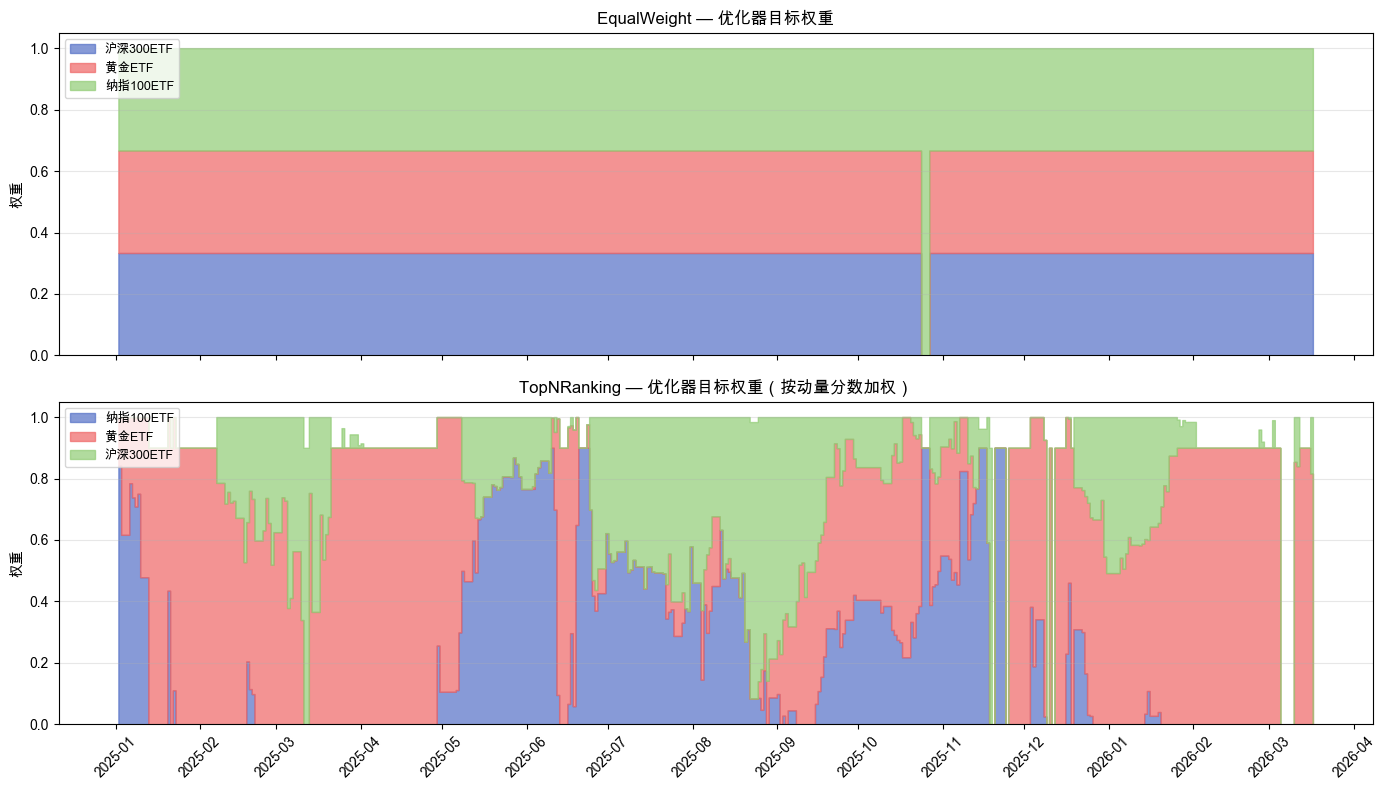

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

COLORS = ["#5470c6", "#ee6666", "#91cc75"]  # blue, red, green


def plot_step_area(ax, df, cols, colors=COLORS):
    """Stacked area chart with step (post) interpolation."""
    x = df.index
    cumulative = np.zeros(len(df))
    for i, col in enumerate(cols):
        y = df[col].values.astype(float)
        ax.fill_between(x, cumulative, cumulative + y,
                        step="post", alpha=0.7, color=colors[i % len(colors)], label=col)
        cumulative = cumulative + y


asset_cols_ew = [c for c in weights_ew.columns if c != "CASH"]
asset_cols_topn = [c for c in weights_topn.columns if c != "CASH"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- 上图：EqualWeight ---
plot_step_area(axes[0], weights_ew, asset_cols_ew)
axes[0].set_ylabel("权重")
axes[0].set_title("EqualWeight — 优化器目标权重")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# --- 下图：TopNRanking ---
plot_step_area(axes[1], weights_topn, asset_cols_topn)
axes[1].set_ylabel("权重")
axes[1].set_title("TopNRanking — 优化器目标权重（按动量分数加权）")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="upper left", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. 持仓变化

`result.positions_df()` 返回每日持仓股数的 DataFrame。

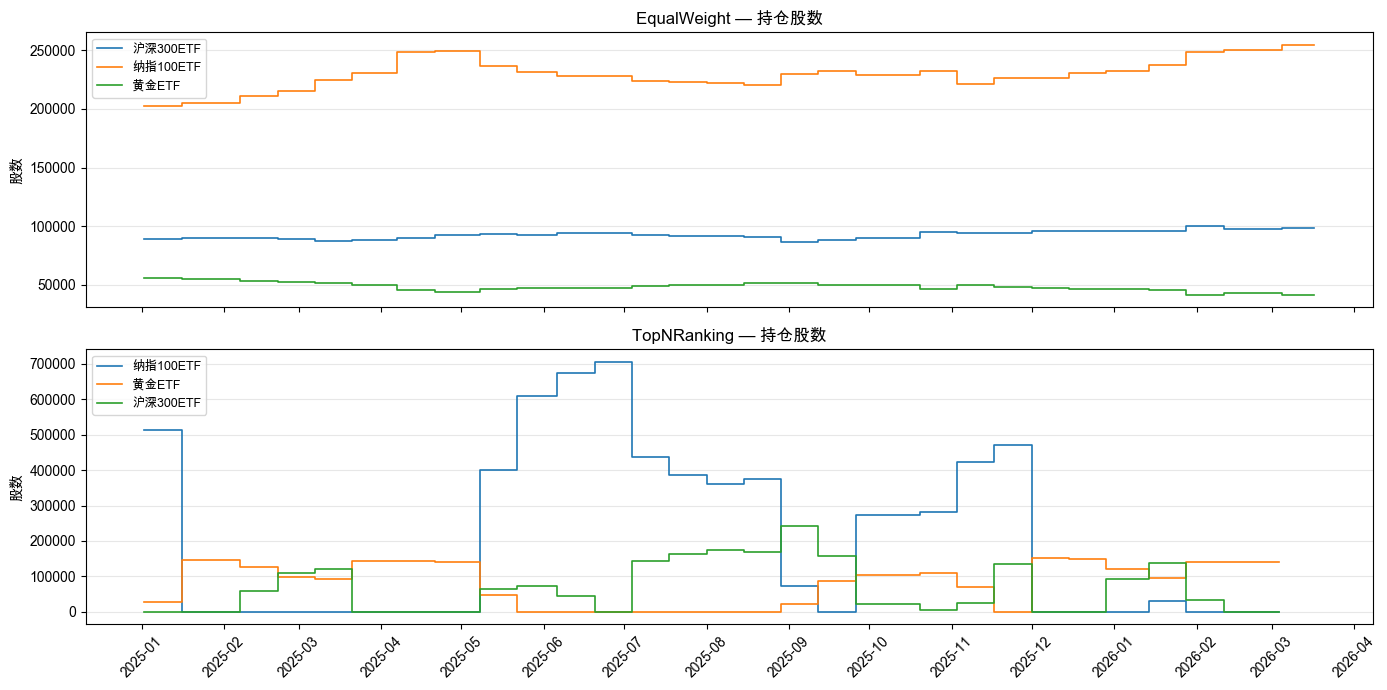

In [7]:
positions_ew = rename_cols(result_ew.positions_df())
positions_topn = rename_cols(result_topn.positions_df())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, pos, title in [
    (axes[0], positions_ew, "EqualWeight — 持仓股数"),
    (axes[1], positions_topn, "TopNRanking — 持仓股数"),
]:
    for col in pos.columns:
        ax.step(pos.index, pos[col], where="post", label=col, linewidth=1.2)
    ax.set_ylabel("股数")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. 权益曲线 + 权重联合视图

将两个策略的权益曲线和权重变化放在同一张图上对比。

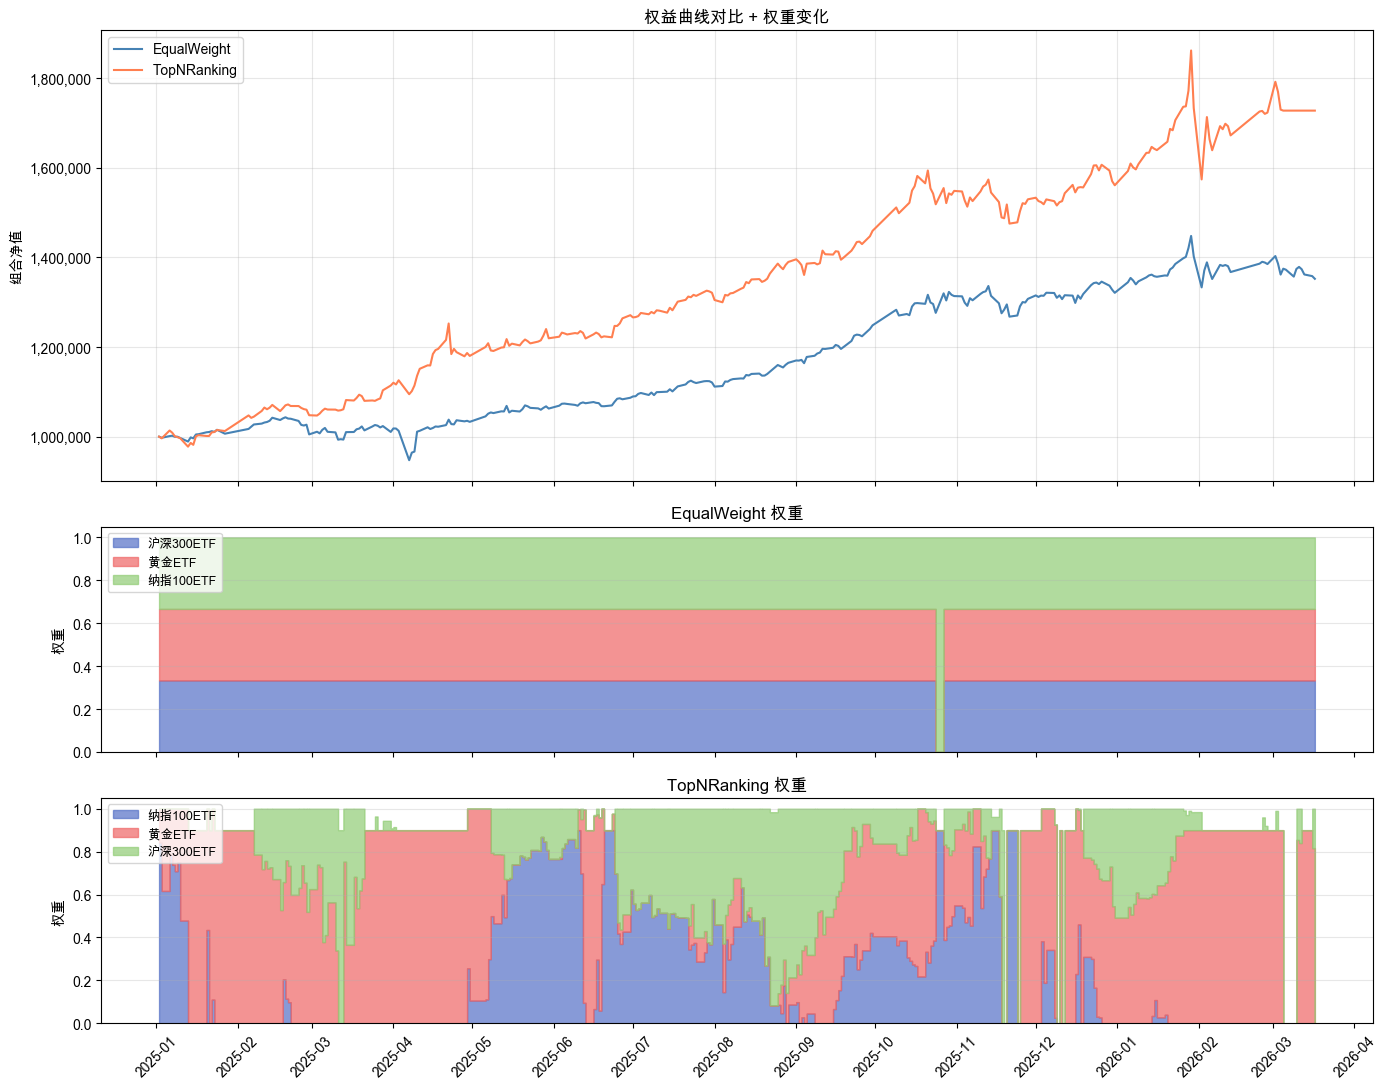

In [8]:
import pandas as pd

fig, axes = plt.subplots(
    3, 1, figsize=(14, 11), sharex=True,
    gridspec_kw={"height_ratios": [2, 1, 1]},
)

# --- 上图：两条权益曲线 ---
ax_eq = axes[0]
for result, label, color in [
    (result_ew, "EqualWeight", "steelblue"),
    (result_topn, "TopNRanking", "coral"),
]:
    dates = [d for d, _ in result.equity_curve]
    values = [v for _, v in result.equity_curve]
    ax_eq.plot(dates, values, color=color, linewidth=1.5, label=label)
ax_eq.set_ylabel("组合净值")
ax_eq.set_title("权益曲线对比 + 权重变化")
ax_eq.legend(fontsize=10)
ax_eq.grid(alpha=0.3)
ax_eq.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# --- 中图：EqualWeight 权重 ---
plot_step_area(axes[1], weights_ew, asset_cols_ew)
axes[1].set_ylabel("权重")
axes[1].set_title("EqualWeight 权重")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="upper left", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

# --- 下图：TopNRanking 权重 ---
plot_step_area(axes[2], weights_topn, asset_cols_topn)
axes[2].set_ylabel("权重")
axes[2].set_title("TopNRanking 权重")
axes[2].set_ylim(0, 1.05)
axes[2].legend(loc="upper left", fontsize=9)
axes[2].grid(axis="y", alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. 逐 bar 快照明细

每个 `BarSnapshot` 包含完整的当日信息：优化器权重、调整后权重、持仓、现金、总资产。

In [9]:
for name, result in [("EqualWeight", result_ew), ("TopNRanking", result_topn)]:
    snap = result.snapshots[-1]
    print(f"=== {name} 最后一个快照 ({snap.date}) ===")
    print(f"  优化器权重: {snap.target_weights}")
    print(f"  调整后权重: {snap.adjusted_weights}")
    print(f"  现金: {snap.cash:,.2f}")
    print(f"  总资产: {snap.total_value:,.2f}")
    print(f"  持仓:")
    for sym, ps in snap.positions.items():
        print(f"    {SYMBOL_NAMES.get(sym, sym)}: {ps.shares} 股, 均价 {ps.avg_cost:.4f}")
    print()

=== EqualWeight 最后一个快照 (2026-03-17 00:00:00) ===
  优化器权重: {'510300.SS': 0.3333333333333333, '518880.SS': 0.3333333333333333, '513100.SS': 0.3333333333333333}
  调整后权重: {'510300.SS': 0.3333333333333333, '518880.SS': 0.3333333333333333, '513100.SS': 0.3333333333333333}
  现金: 1,506.95
  总资产: 1,352,192.24
  持仓:
    沪深300ETF: 98400 股, 均价 3.8643
    纳指100ETF: 254500 股, 均价 1.6485
    黄金ETF: 41700 股, 均价 6.4494

=== TopNRanking 最后一个快照 (2026-03-17 00:00:00) ===
  优化器权重: {'CASH': 1.0}
  调整后权重: {'CASH': 1.0}
  现金: 1,727,467.19
  总资产: 1,727,467.19
  持仓:

